In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
R

plt.style.use("ggplot")

print("All libraries imported successfully!")


All libraries imported successfully!


# Titanic Exploratory Data Analysis (EDA)

## Objective
This notebook performs exploratory data analysis (EDA) on the Titanic dataset. The goal is to clean the data, explore important features, visualize survival patterns, and summarize key findings without building any machine learning model.

In [2]:
df = pd.read_csv("../data/titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (891, 12)


In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Data Cleaning

The dataset contains missing values in the Age, Cabin, and Embarked columns.

- Missing Age values will be replaced with the median because the median is less affected by outliers.
- Missing Embarked values will be replaced with the most frequent value (mode).
- The Cabin column contains too many missing values (687 out of 891), so it will be removed.

# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column
df = df.drop(columns=["Cabin"])

# Verify that missing values are handled
df.isnull().sum()

In [8]:
# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column
df = df.drop(columns=["Cabin"])

# Verify that missing values are handled
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## 1. Survival Count

This chart shows the number of passengers who survived and those who did not survive.

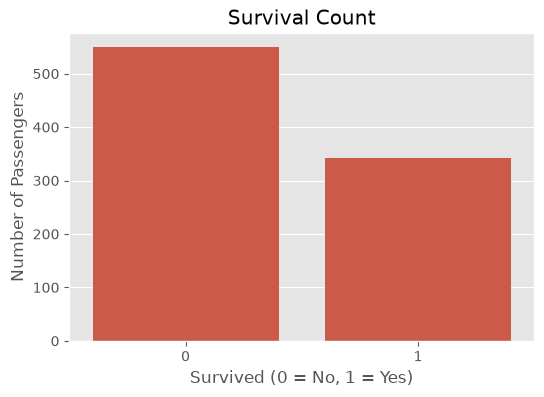

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Survived")

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.savefig("../images/survival_count.png")
plt.show()

### Observation

The number of passengers who did not survive is higher than the number of passengers who survived.

## 2. Gender vs Survival

This chart compares survival based on gender.

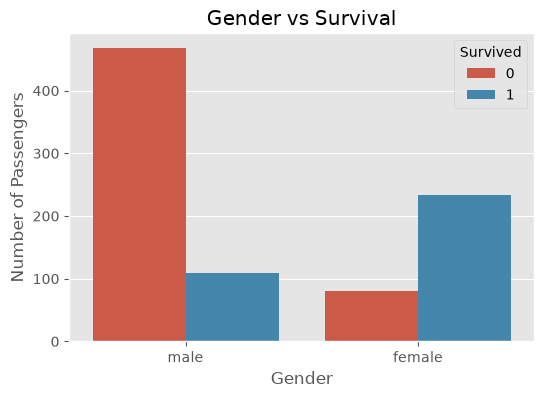

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Gender vs Survival")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.savefig("../images/gender_survival.png")
plt.show()

### Observation

Female passengers had a much higher survival rate than male passengers.

## 3. Passenger Class vs Survival

This chart shows survival according to passenger class.

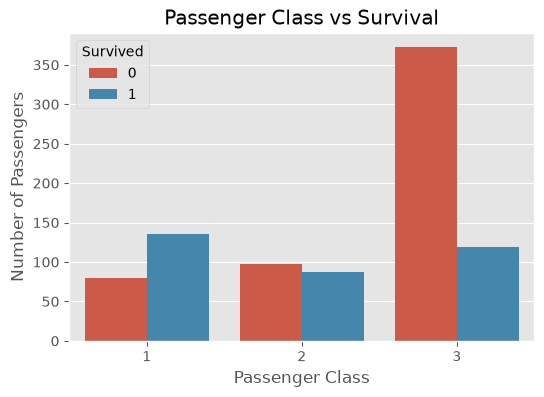

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Passenger Class vs Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.savefig("../images/class_survival.png")
plt.show()

### Observation

Passengers traveling in first class survived more often than passengers in third class.

## 4. Age Distribution

This histogram shows the distribution of passenger ages.

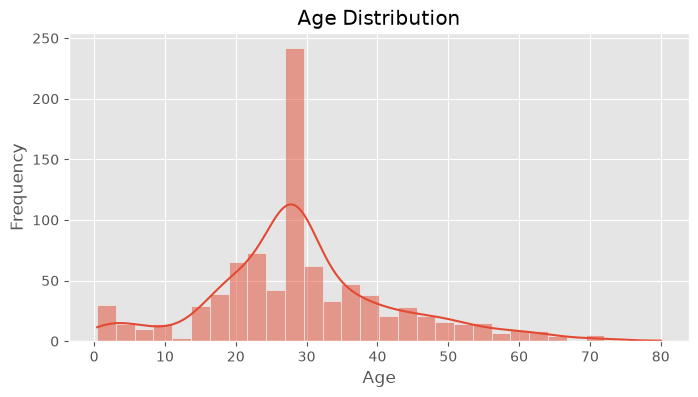

In [13]:
plt.figure(figsize=(8,4))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.savefig("../images/age_distribution.png")
plt.show()

### Observation

Most passengers were between 20 and 40 years old.

## 5. Fare Distribution

This histogram shows how ticket fares were distributed among passengers.

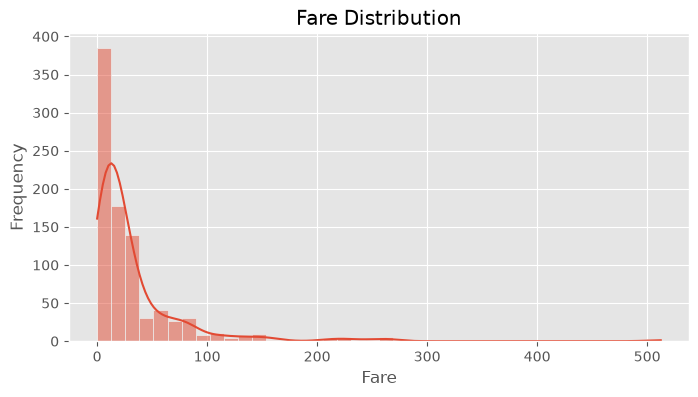

In [14]:
plt.figure(figsize=(8,4))

sns.histplot(df["Fare"], bins=40, kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.savefig("../images/fare_distribution.png")
plt.show()

### Observation

Most passengers paid relatively low fares, while only a few passengers paid very high fares.

## 6. Correlation Heatmap

The heatmap shows the correlation between numerical variables in the dataset.

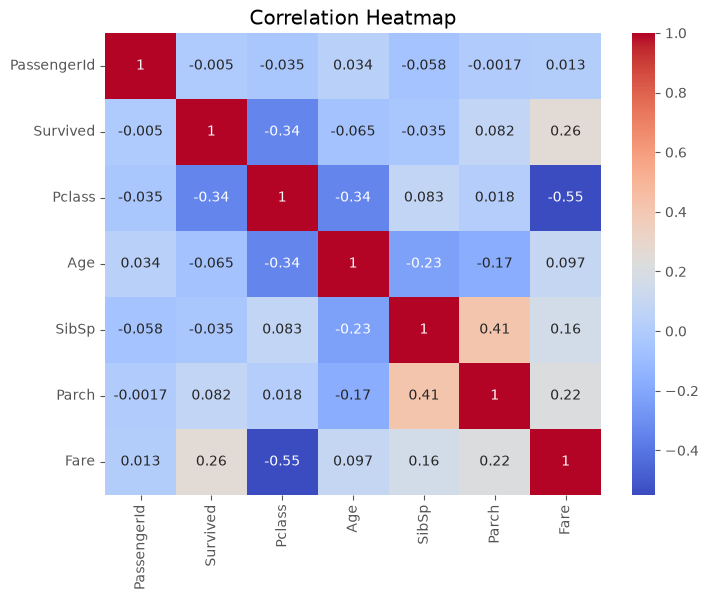

In [15]:
plt.figure(figsize=(8,6))

numeric = df.select_dtypes(include=["number"])

sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.savefig("../images/correlation_heatmap.png")
plt.show()

### Observation

Passenger class and fare have noticeable relationships with survival. Other numerical features show weaker correlations.

# Findings

This exploratory data analysis (EDA) examined the Titanic dataset to understand the factors that influenced passenger survival. The dataset was cleaned by replacing missing values in the Age column with the median and filling missing values in the Embarked column with the most frequent value. The Cabin column was removed because it contained a large number of missing values. The analysis showed that more passengers died than survived. Female passengers had a significantly higher survival rate than male passengers. Passenger class also played an important role, with first-class passengers surviving more often than those in third class. Most passengers were between 20 and 40 years old, and the majority paid relatively low ticket fares. The correlation heatmap showed that passenger class and fare had the strongest relationship with survival. This analysis provides useful insights into the dataset and prepares it for future machine learning models.